IMPORTING NECESSARY LIBRARIES


In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
categorized_tags_file = '../Data/FinalDataset/CategorizedTags.txt'  
categories = {}
current_category = None

In [3]:
with open(categorized_tags_file, 'r') as file:
    for line in file:
        line = line.strip()
        if line.startswith("###"): 
            current_category = line.replace("###", "").strip()
            categories[current_category] = []
        elif line:  
            categories[current_category].append(line.lower())

In [4]:
tag_to_category = {}
for category, tags in categories.items():
    for tag in tags:
        tag_to_category[tag] = category

In [5]:
file_path = '../Data/FinalDataset/data.csv'  
data = pd.read_csv(file_path)

ONE-HOT ENCODING FOR PROVINCES 

In [6]:
province_encoder = OneHotEncoder(sparse_output=False)  # Updated parameter for sklearn compatibility
province_encoded = province_encoder.fit_transform(data[['province']])
province_encoded_df = pd.DataFrame(province_encoded, columns=province_encoder.get_feature_names_out(['province']))

MULTI-HOT ENCODING FOR TAGS

In [7]:
def categorize_tags(tags):
    categories_set = set()
    for tag in tags.split(','):
        tag = tag.strip().lower()  
        if tag in tag_to_category:
            categories_set.add(tag_to_category[tag])
    return list(categories_set)

data['categories'] = data['tags'].apply(categorize_tags)

In [8]:
unique_categories = set(cat for categories in data['categories'] for cat in categories)

In [9]:
def multi_hot_encode(categories, unique_categories):
    return [1 if cat in categories else 0 for cat in unique_categories]

category_encoded = data['categories'].apply(lambda x: multi_hot_encode(x, unique_categories))
category_encoded_df = pd.DataFrame(category_encoded.tolist(), columns=list(unique_categories))


In [10]:
encoded_df = pd.concat([data, province_encoded_df, category_encoded_df], axis=1)


In [11]:
output_file_path = "Output/encoded_data.csv"
encoded_df.to_csv(output_file_path, index=False)
print(f"Categorized and encoded data saved to {output_file_path}")

Categorized and encoded data saved to Output/encoded_data.csv


VISUALIZATION

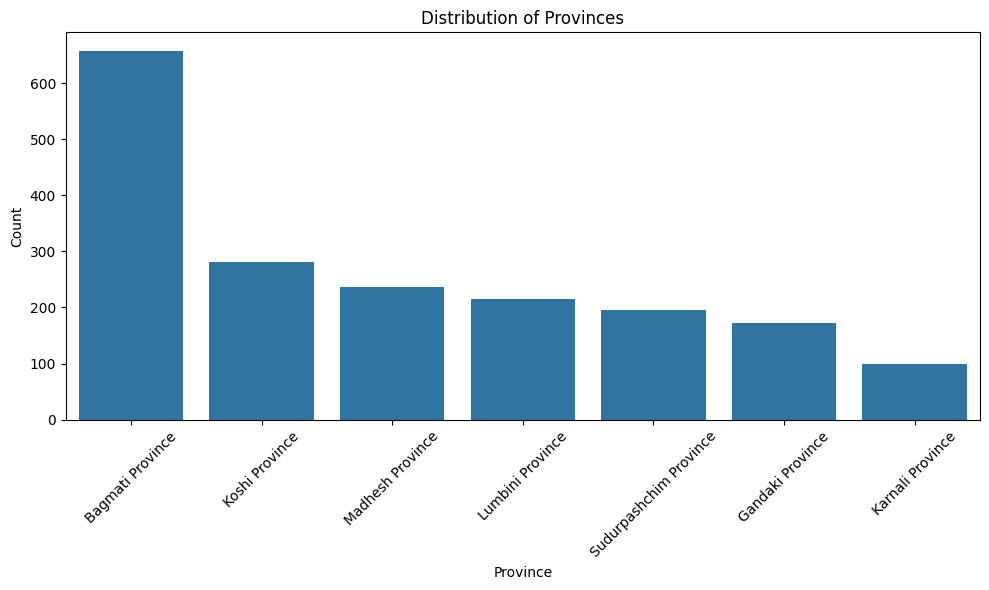

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='province', order=data['province'].value_counts().index)
plt.title('Distribution of Provinces')
plt.xlabel('Province')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("province_distribution.png") 
plt.show()

C:\Users\sussh\AppData\Local\Temp\ipykernel_2760\2662028543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


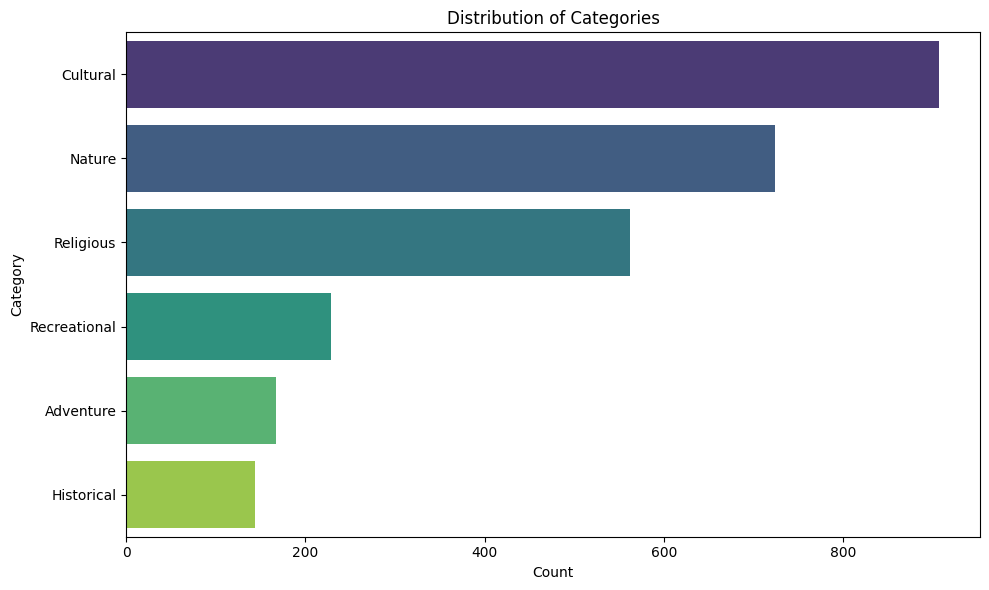

In [13]:
category_counts = category_encoded_df.sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Distribution of Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig("category_distribution.png")  # Save the plot as an image file
plt.show()